### Step 1: Environment & Hyperparameters
We use CliffWalking-v0. The key here is the 30 seeds requirement to calculate the 95% Confidence Interval.

In [1]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

env = gym.make('CliffWalking-v0')

# Hyperparameters
alpha = 0.1
gamma = 0.99
epsilon = 0.1
episodes = 500
seeds = 30  # Required for 95% Confidence Interval

### Step 2: SARSA & Q-Learning Implementations
This logic performs online updates (after every step) as requested.

In [2]:
def train_agent(algorithm="q_learning"):
    all_seed_rewards = []
    
    for seed in range(seeds):
        q_table = np.zeros((env.observation_space.n, env.action_space.n))
        episode_rewards = []
        
        for i in range(episodes):
            state, _ = env.reset(seed=seed)
            total_reward = 0
            
            # Action selection for start of episode
            def get_action(s):
                if np.random.random() < epsilon:
                    return env.action_space.sample()
                return np.argmax(q_table[s])

            action = get_action(state)
            
            while True:
                next_state, reward, terminated, truncated, _ = env.step(action)
                
                if algorithm == "sarsa":
                    next_action = get_action(next_state)
                    # SARSA Target: R + gamma * Q(s', a')
                    td_target = reward + gamma * q_table[next_state, next_action] * (not terminated)
                    q_table[state, action] += alpha * (td_target - q_table[state, action])
                    action = next_action
                else:
                    # Q-Learning Target: R + gamma * max(Q(s'))
                    td_target = reward + gamma * np.max(q_table[next_state]) * (not terminated)
                    q_table[state, action] += alpha * (td_target - q_table[state, action])
                    action = get_action(next_state)

                state = next_state
                total_reward += reward
                if terminated or truncated:
                    break
            episode_rewards.append(total_reward)
        all_seed_rewards.append(episode_rewards)
        
    return np.array(all_seed_rewards), q_table

sarsa_rewards, sarsa_q = train_agent("sarsa")
ql_rewards, ql_q = train_agent("q_learning")

### Step 3: Learning Curves with 95% CI
This generates the quantitative support the professor asked for.

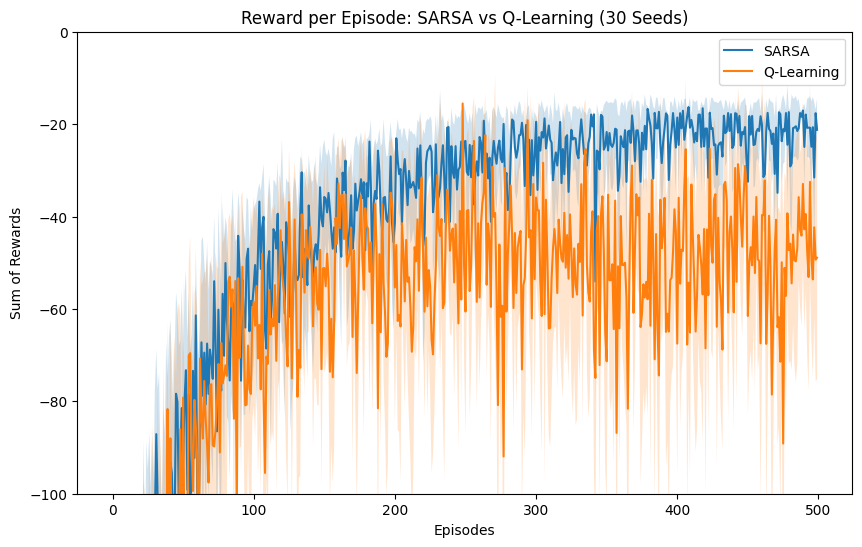

In [3]:
def plot_comparison(sarsa_data, ql_data):
    plt.figure(figsize=(10, 6))
    
    for data, label in zip([sarsa_data, ql_data], ["SARSA", "Q-Learning"]):
        mean = np.mean(data, axis=0)
        std = np.std(data, axis=0)
        # 95% CI formula: 1.96 * (std / sqrt(n))
        ci = 1.96 * (std / np.sqrt(seeds))
        
        plt.plot(mean, label=label)
        plt.fill_between(range(episodes), mean - ci, mean + ci, alpha=0.2)
        
    plt.ylim(-100, 0) # Focus on the convergence area
    plt.title("Reward per Episode: SARSA vs Q-Learning (30 Seeds)")
    plt.xlabel("Episodes")
    plt.ylabel("Sum of Rewards")
    plt.legend()
    plt.show()

plot_comparison(sarsa_rewards, ql_rewards)

### Step 4: Value Function Heatmap & Policy Arrows
This addresses the specific "Deliverables" penalty ($-5$ points).

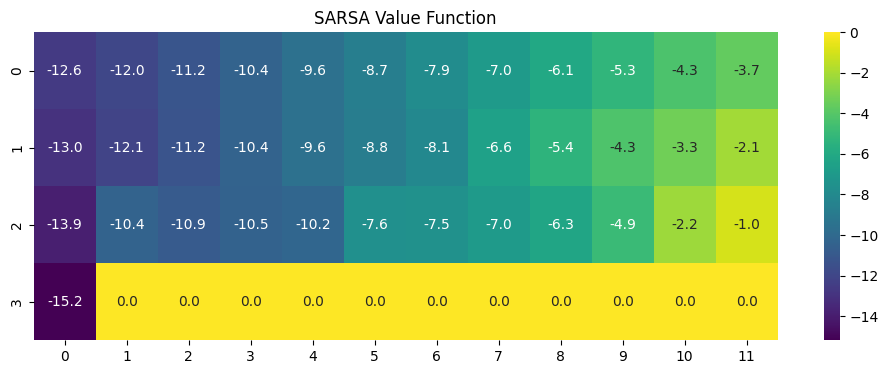


SARSA Policy (0=U, 1=R, 2=D, 3=L):
[[1 1 1 1 1 1 1 1 1 2 2 2]
 [1 1 1 1 1 1 2 1 1 1 1 2]
 [0 0 1 0 0 1 1 0 0 3 1 2]
 [0 0 0 0 0 0 0 0 0 0 0 0]]


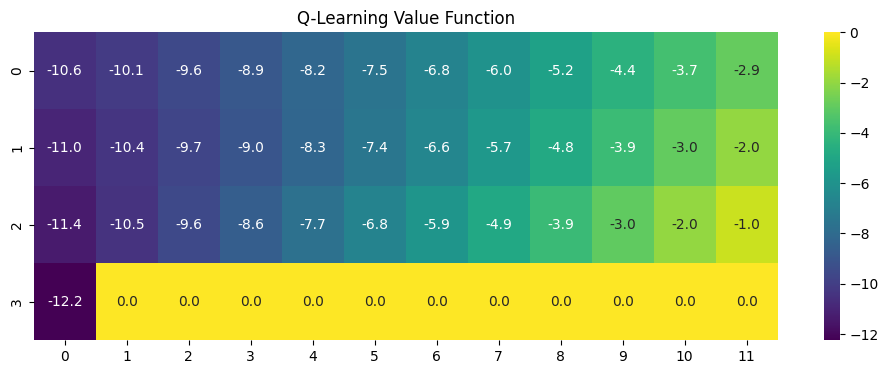


Q-Learning Policy (0=U, 1=R, 2=D, 3=L):
[[0 1 1 1 0 1 2 1 1 2 1 2]
 [2 0 3 1 0 1 1 1 1 2 2 2]
 [1 1 1 1 1 1 1 1 1 1 1 2]
 [0 0 0 0 0 0 0 0 0 0 0 0]]


In [4]:
def plot_policy_map(q_table, title):
    # Value Function Heatmap
    v_function = np.max(q_table, axis=1).reshape(4, 12)
    plt.figure(figsize=(12, 4))
    sns.heatmap(v_function, annot=True, fmt=".1f", cmap="viridis")
    plt.title(f"{title} Value Function")
    plt.show()

    # Policy Arrows
    actions = np.argmax(q_table, axis=1).reshape(4, 12)
    print(f"\n{title} Policy (0=U, 1=R, 2=D, 3=L):")
    print(actions)

plot_policy_map(sarsa_q, "SARSA")
plot_policy_map(ql_q, "Q-Learning")